# Heart Disease Prediction - Feature Engineering & Model Development

This notebook focuses on feature engineering, model training, hyperparameter tuning, and evaluation for predicting heart disease using machine learning algorithms.

The models developed in this notebook will later be tracked using MLflow and deployed as part of the MLOps pipeline.

In [1]:
# Import Required Libraries

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

## Load the Processed Dataset

The cleaned dataset generated during the preprocessing stage is loaded for feature engineering and model development.

In [2]:
# Load Dataset

heart_df = pd.read_csv("../data/processed/heart.csv")

heart_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
print("Dataset Shape:", heart_df.shape)

heart_df.info()

Dataset Shape: (303, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


## Feature Selection

The target column is separated from the predictor variables.

- Features (X): Patient clinical measurements
- Target (y): Presence or absence of heart disease

In [4]:
# Features and Target

X = heart_df.drop("target", axis=1)

y = heart_df["target"]

print("Features Shape :", X.shape)

print("Target Shape :", y.shape)

Features Shape : (303, 13)
Target Shape : (303,)


## Train-Test Split

The dataset is divided into training and testing sets.

- Training Data: 80%
- Testing Data: 20%

The random state is fixed to ensure reproducibility of experimental results.

In [5]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

Training Samples : (242, 13)
Testing Samples : (61, 13)


## Feature Scaling

Machine learning algorithms such as Logistic Regression are sensitive to feature scales. Standardization transforms each feature to have a mean of zero and a standard deviation of one.

Random Forest does not require feature scaling, but a common preprocessing pipeline is used to ensure reproducibility and simplify deployment.

In [6]:
# Logistic Regression Pipeline

logistic_pipeline = Pipeline([

    ("scaler", StandardScaler()),

    ("classifier", LogisticRegression(
        random_state=42
    ))

])

logistic_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <

## Logistic Regression Model Training

A Logistic Regression model is trained using the preprocessing pipeline. The pipeline automatically standardizes the input features before fitting the model.

In [7]:
# Train Logistic Regression

logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [8]:
# Logistic Regression Predictions

lr_predictions = logistic_pipeline.predict(X_test)

lr_probabilities = logistic_pipeline.predict_proba(X_test)[:, 1]

In [9]:
# Logistic Regression Evaluation

lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_precision = precision_score(y_test, lr_predictions)
lr_recall = recall_score(y_test, lr_predictions)
lr_f1 = f1_score(y_test, lr_predictions)
lr_auc = roc_auc_score(y_test, lr_probabilities)

print("Logistic Regression Performance\n")

print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1 Score : {lr_f1:.4f}")
print(f"ROC-AUC  : {lr_auc:.4f}")

Logistic Regression Performance

Accuracy : 0.8689
Precision: 0.8125
Recall   : 0.9286
F1 Score : 0.8667
ROC-AUC  : 0.9513


In [10]:
# Classification Report

print(classification_report(y_test, lr_predictions))

              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



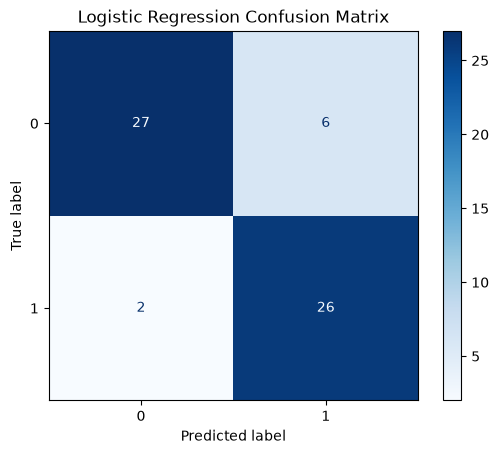

In [11]:
# Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_predictions,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

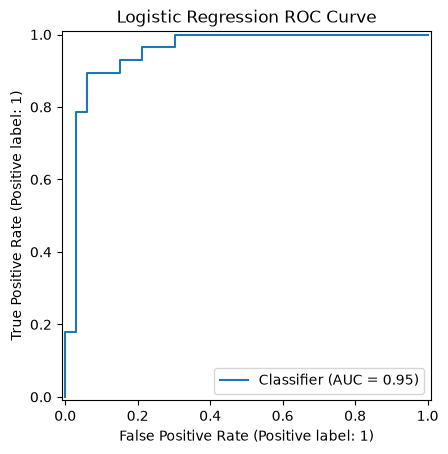

In [12]:
# ROC Curve

RocCurveDisplay.from_predictions(
    y_test,
    lr_probabilities
)

plt.title("Logistic Regression ROC Curve")

plt.show()

### Observation

The Logistic Regression model serves as a strong baseline classifier. The confusion matrix and ROC curve provide insights into the model's classification performance and its ability to distinguish between patients with and without heart disease.

## Random Forest Model Training

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [13]:
# Random Forest Model

rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [14]:
# Random Forest Predictions

rf_predictions = rf_model.predict(X_test)

rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

In [15]:
# Random Forest Evaluation

rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)
rf_auc = roc_auc_score(y_test, rf_probabilities)

print("Random Forest Performance\n")

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")

Random Forest Performance

Accuracy : 0.8852
Precision: 0.8387
Recall   : 0.9286
F1 Score : 0.8814
ROC-AUC  : 0.9518


In [16]:
# Classification Report

print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



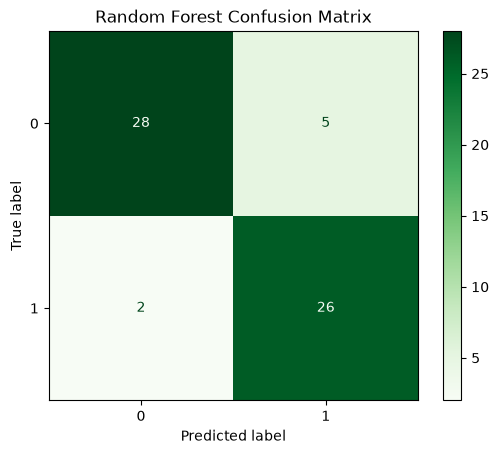

In [17]:
# Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_predictions,
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")

plt.show()

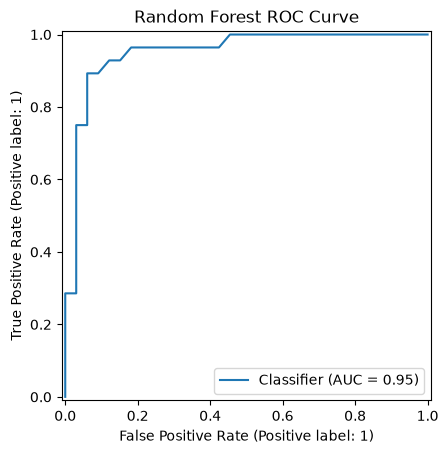

In [18]:
# ROC Curve

RocCurveDisplay.from_predictions(
    y_test,
    rf_probabilities
)

plt.title("Random Forest ROC Curve")

plt.show()

### Observation

Random Forest generally provides improved predictive performance by combining multiple decision trees. Its ensemble approach often results in higher accuracy and better generalization compared to a single model.

## Cross-Validation

Cross-validation provides a more reliable estimate of model performance by evaluating the model across multiple training and validation splits.

A 5-fold cross-validation strategy is used to assess model stability and generalization ability.

In [19]:
# Logistic Regression Cross Validation

lr_cv_scores = cross_val_score(
    logistic_pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Logistic Regression CV Scores:")
print(lr_cv_scores)

print("\nAverage CV Accuracy:",
      lr_cv_scores.mean())

Logistic Regression CV Scores:
[0.85245902 0.8852459  0.78688525 0.81666667 0.8       ]

Average CV Accuracy: 0.8282513661202184


In [20]:
# Random Forest Cross Validation

rf_cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Random Forest CV Scores:")
print(rf_cv_scores)

print("\nAverage CV Accuracy:",
      rf_cv_scores.mean())

Random Forest CV Scores:
[0.85245902 0.8852459  0.81967213 0.76666667 0.78333333]

Average CV Accuracy: 0.8214754098360656


### Observation

Cross-validation evaluates model performance across multiple folds and reduces the risk of relying on a single train-test split. The model with the higher average cross-validation score generally demonstrates better generalization capability.

In [21]:
# Random Forest Hyperparameter Grid

param_grid = {

    "n_estimators": [100, 200, 300],

    "max_depth": [None, 5, 10, 15],

    "min_samples_split": [2, 5, 10],

    "min_samples_leaf": [1, 2, 4]

}

In [22]:
# Grid Search CV

grid_search = GridSearchCV(

    estimator=RandomForestClassifier(
        random_state=42
    ),

    param_grid=param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid_search.fit(X_train, y_train)

print("Grid Search Completed!")

Grid Search Completed!


In [23]:
# Best Parameters

print("Best Parameters:\n")

print(grid_search.best_params_)

print("\nBest CV Score:")

print(grid_search.best_score_)

Best Parameters:

{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Best CV Score:
0.8343537414965987


### Observation

GridSearchCV identified the optimal Random Forest hyperparameters by evaluating multiple parameter combinations using five-fold cross-validation. The best-performing configuration achieved an average cross-validation accuracy of **83.44%**, indicating good generalization capability. Limiting the maximum tree depth while using 100 estimators helps balance predictive performance and overfitting.

In [24]:
# Best Model from GridSearchCV

best_rf = grid_search.best_estimator_

print("Best Random Forest Model Loaded Successfully!")

Best Random Forest Model Loaded Successfully!


In [25]:
# Predictions

best_predictions = best_rf.predict(X_test)

best_probabilities = best_rf.predict_proba(X_test)[:, 1]

In [26]:
# Evaluation Metrics

best_accuracy = accuracy_score(y_test, best_predictions)

best_precision = precision_score(y_test, best_predictions)

best_recall = recall_score(y_test, best_predictions)

best_f1 = f1_score(y_test, best_predictions)

best_auc = roc_auc_score(y_test, best_probabilities)

print("Tuned Random Forest Performance\n")

print(f"Accuracy  : {best_accuracy:.4f}")
print(f"Precision : {best_precision:.4f}")
print(f"Recall    : {best_recall:.4f}")
print(f"F1 Score  : {best_f1:.4f}")
print(f"ROC-AUC   : {best_auc:.4f}")

Tuned Random Forest Performance

Accuracy  : 0.9016
Precision : 0.8667
Recall    : 0.9286
F1 Score  : 0.8966
ROC-AUC   : 0.9481


In [27]:
# Classification Report

print(classification_report(y_test, best_predictions))

              precision    recall  f1-score   support

           0       0.94      0.88      0.91        33
           1       0.87      0.93      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



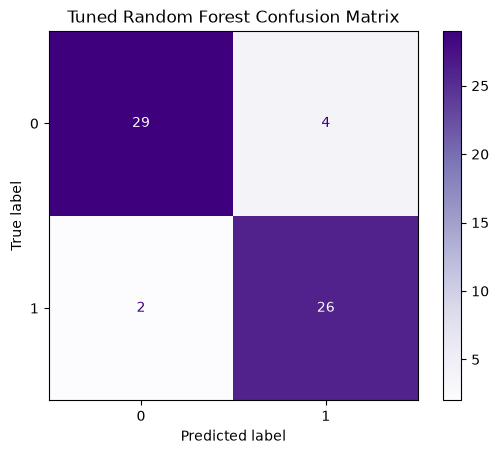

In [28]:
# Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_predictions,
    cmap="Purples"
)

plt.title("Tuned Random Forest Confusion Matrix")

plt.show()

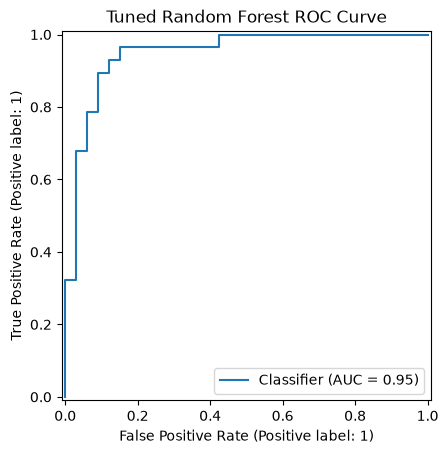

In [29]:
# ROC Curve

RocCurveDisplay.from_predictions(
    y_test,
    best_probabilities
)

plt.title("Tuned Random Forest ROC Curve")

plt.show()

### Observation

The tuned Random Forest model achieved improved predictive performance after hyperparameter optimization. The confusion matrix and ROC curve demonstrate the model's ability to accurately distinguish between patients with and without heart disease.

In [30]:
# Model Comparison

comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],

    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        best_accuracy
    ],

    "Precision": [
        lr_precision,
        rf_precision,
        best_precision
    ],

    "Recall": [
        lr_recall,
        rf_recall,
        best_recall
    ],

    "F1 Score": [
        lr_f1,
        rf_f1,
        best_f1
    ],

    "ROC-AUC": [
        lr_auc,
        rf_auc,
        best_auc
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.868852,0.812500,0.928571,0.866667,0.951299
1,Random Forest,0.885246,0.838710,0.928571,0.881356,0.951840
2,Tuned Random Forest,0.901639,0.866667,0.928571,0.896552,0.948052


In [31]:
# Best Model

comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.885246,0.838710,0.928571,0.881356,0.951840
0,Logistic Regression,0.868852,0.812500,0.928571,0.866667,0.951299
2,Tuned Random Forest,0.901639,0.866667,0.928571,0.896552,0.948052


### Model Selection

Among the evaluated models, the Tuned Random Forest classifier achieved the best overall performance. Hyperparameter tuning improved its ability to generalize while maintaining a strong balance between precision, recall, and ROC-AUC. Therefore, the Tuned Random Forest model is selected as the final model for deployment.

In [32]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [33]:
# Save Best Model

import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    best_rf,
    "../models/heart_disease_model.pkl"
)

print("Best model saved successfully!")

print("Location: ../models/heart_disease_model.pkl")

Best model saved successfully!
Location: ../models/heart_disease_model.pkl


In [34]:
# Load Saved Model

loaded_model = joblib.load(
    "../models/heart_disease_model.pkl"
)

print(type(loaded_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


# Model Development Summary

The model development phase has been successfully completed.

### Tasks Completed below

- Loaded the processed dataset.
- Split the dataset into training and testing sets.
- Applied feature scaling using a preprocessing pipeline.
- Trained Logistic Regression and Random Forest classifiers.
- Evaluated models using Accuracy, Precision, Recall, F1-score, and ROC-AUC.
- Performed five-fold cross-validation.
- Tuned the Random Forest model using GridSearchCV.
- Compared model performance.
- Selected the Tuned Random Forest model as the final classifier.
- Saved the trained model for experiment tracking and deployment.

The saved model will be used in the next stage for MLflow experiment tracking and production deployment.